# **1. Problem Definition**

- Credit card companies are continously lending out money and these companies always face the risk of customers failing to repay their debt. As data scientist we can identify these high risks clients to minimize financial losses and make data driven decisions. Who of our customers is going to default?

- The objective is to gather valuable information to build a machine learning model that allows to see and predicts wheter a client will default on their credit card payment in the next month based on historical financial and behavioral data

- Input = customer data
- Output = default [0/1]

- To even grasp the problem better, understanding and explaining the key factors that drive default risk is a necessity. We will touch upon explainability and XAI.

# **2. Import Libraries**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from ydata_profiling import ProfileReport

# **3. Load the Data**

In [ ]:
df = pd.read_csv(r"C:\Users\jensd\Downloads\Datasets School\Data Science Map\credit-risk-project\data\raw\UCI_Credit_Card.csv")

# **4. Sanity Check**

In [13]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [14]:
print(df.shape)

(30000, 25)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [16]:
df.describe

<bound method NDFrame.describe of           ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0          1    20000.0    2          2         1   24      2      2     -1   
1          2   120000.0    2          2         2   26     -1      2      0   
2          3    90000.0    2          2         2   34      0      0      0   
3          4    50000.0    2          2         1   37      0      0      0   
4          5    50000.0    1          2         1   57     -1      0     -1   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
29995  29996   220000.0    1          3         1   39      0      0      0   
29996  29997   150000.0    1          3         2   43     -1     -1     -1   
29997  29998    30000.0    1          2         2   37      4      3      2   
29998  29999    80000.0    1          3         1   41      1     -1      0   
29999  30000    50000.0    1          2         1   46      0      0      0   

       PAY_4  ...

# **5 Light Cleaning**

In [17]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

**Perfect, no missing values for our dataset.**

In [18]:
df.duplicated().sum()

0

**Also no duplicates, good.**

# **6. Exploratory Data Analysis (EDA)**

**6.1 Pandas Profiling | Check the Basics**

In [ ]:
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)
ProfileReport(df)

### **Cleared the HTML output -> problems with size on GitHub. To check the HTML Pandas Profile report, check "reports" in the folder structure.**

In [ ]:
profile.to_file("../reports/profiling_report.html")

**Short Summary:**
- The dataset contains 30,000 rows and 25 columns.
- There are no missing values in the dataset.
- There are no duplicate rows in the dataset.
- The dataset includes both numerical and categorical features, with a mix of continuous and discrete variables.
- The target variable is 'default.payment.next.month', it appears to be imbalanced (22.1% of the instances are defaults). 
- Skewed distributions: PAY_AMT2 is highly skewed (γ1 = 30.45381745)
- The six BILL_AMT columns are heavily corelated & the six PAY status columns similarly cluster together. This correlation is logic -> the customer's balance is not reseting monthly (need for dimesionality reduction or feature selection?)

**6.2 Target Variable Analysis**

In [21]:
print(df["default.payment.next.month"].value_counts())
print(df["default.payment.next.month"].value_counts(normalize=True)*100)

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


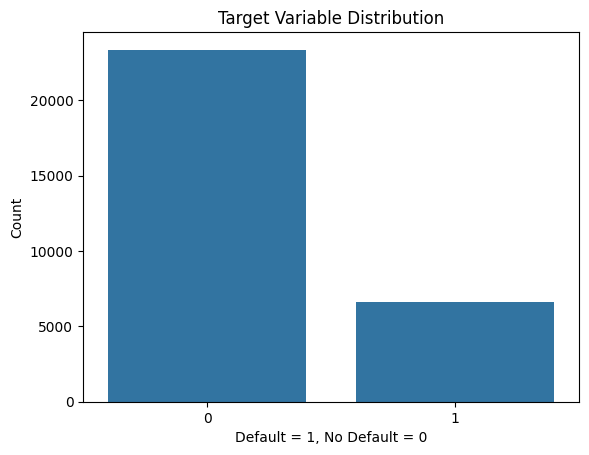

In [22]:
sns.countplot(x="default.payment.next.month", data=df)  
plt.title("Target Variable Distribution")
plt.xlabel("Default = 1, No Default = 0")
plt.ylabel("Count") 
plt.show()

In [23]:
# Average credit limit by default status
print(df.groupby("default.payment.next.month")["LIMIT_BAL"].mean())

default.payment.next.month
0    178099.726074
1    130109.656420
Name: LIMIT_BAL, dtype: float64


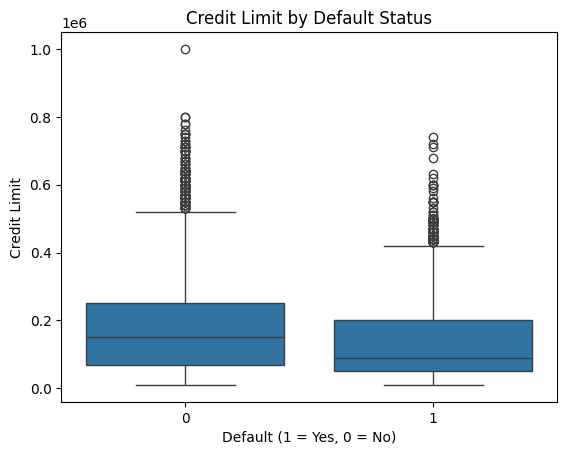

In [24]:
sns.boxplot(x="default.payment.next.month", data=df, y="LIMIT_BAL")
plt.title("Credit Limit by Default Status")
plt.xlabel("Default (1 = Yes, 0 = No)")
plt.ylabel("Credit Limit")
plt.show()

In [25]:
# Default rate by most recent payment status
pay0_default = df.groupby("PAY_0")["default.payment.next.month"].mean() * 100
print(pay0_default)

PAY_0
-2    13.229431
-1    16.778051
 0    12.811291
 1    33.947939
 2    69.141357
 3    75.776398
 4    68.421053
 5    50.000000
 6    54.545455
 7    77.777778
 8    57.894737
Name: default.payment.next.month, dtype: float64


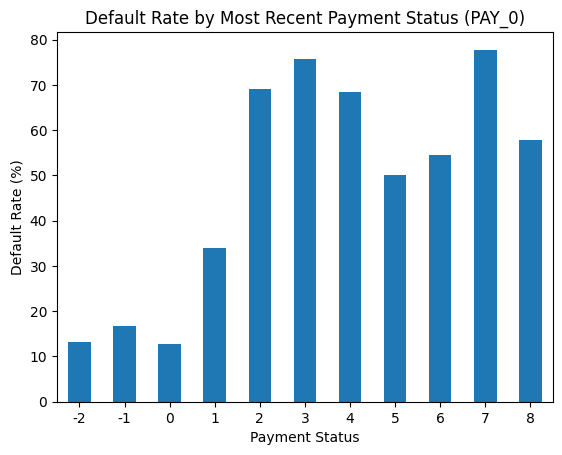

In [26]:
pay0_default.plot(kind="bar")
plt.title("Default Rate by Most Recent Payment Status (PAY_0)")
plt.xlabel("Payment Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.show()

* 77.88% of customers did not default
* 22.12% of customers did default
The dataset is imbalanced. 
- What I can tell:
* Customers who defaulted had on average a significantly lower credit limit than those who didn't.
* The more months a customer has delayed their most recent payment, the dramatically higher their chance of defaulting next month.
- Accuracy is not a suitable metric due to this imbalance, we will probably use recall instead
- PAY_0 is a strong predictor: default rate rises sharply from ~13% for on-time payers to over 75% for customers delayed 3+ months

**6.3 Missing Values Analysis**

In [27]:
print(df.isnull().sum())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

Total missing values: 0


**Missing Values Analysis - Summary** 

- No missing values found in any column (0 out of 750,000 cells)
- No imputation or dropping of rows required
- We can proceed directly to analysis without any missing data treatment

**6.4 Univariate Analysis**

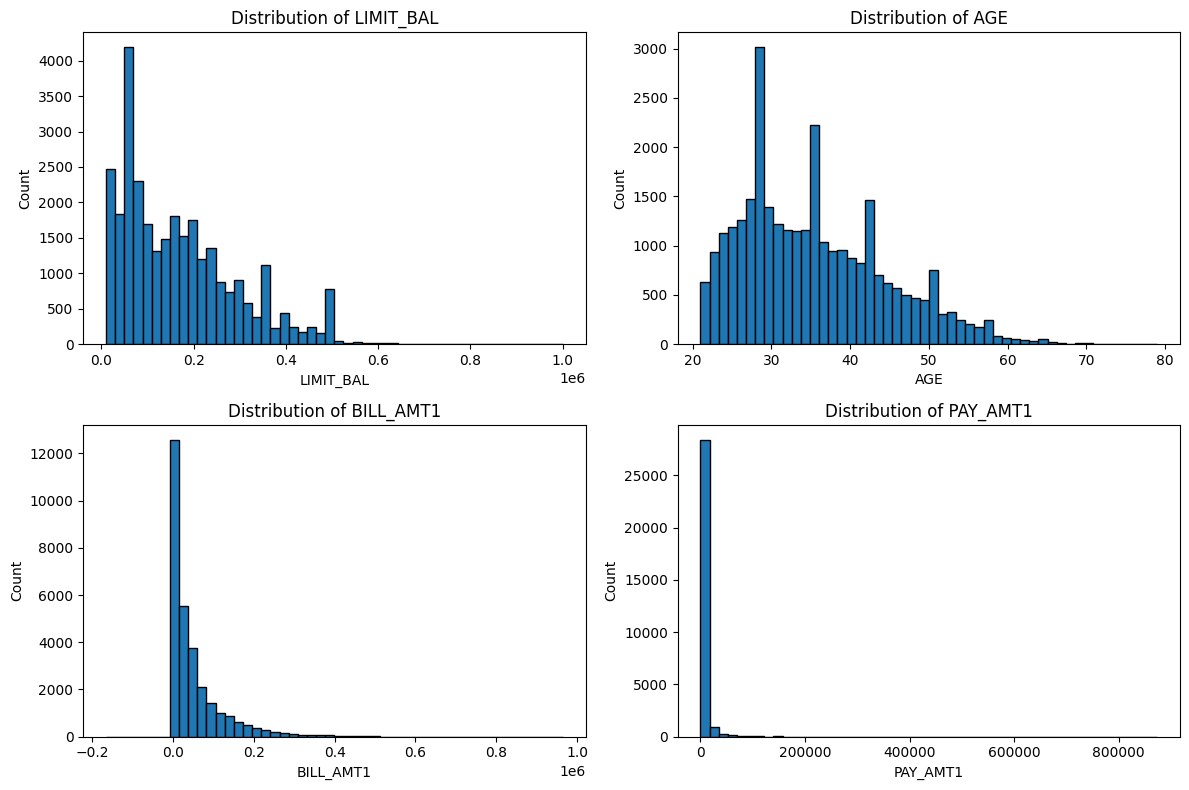

In [28]:
# first numeric features, mainly look at the key ones. 
numeric_features = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=50, edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

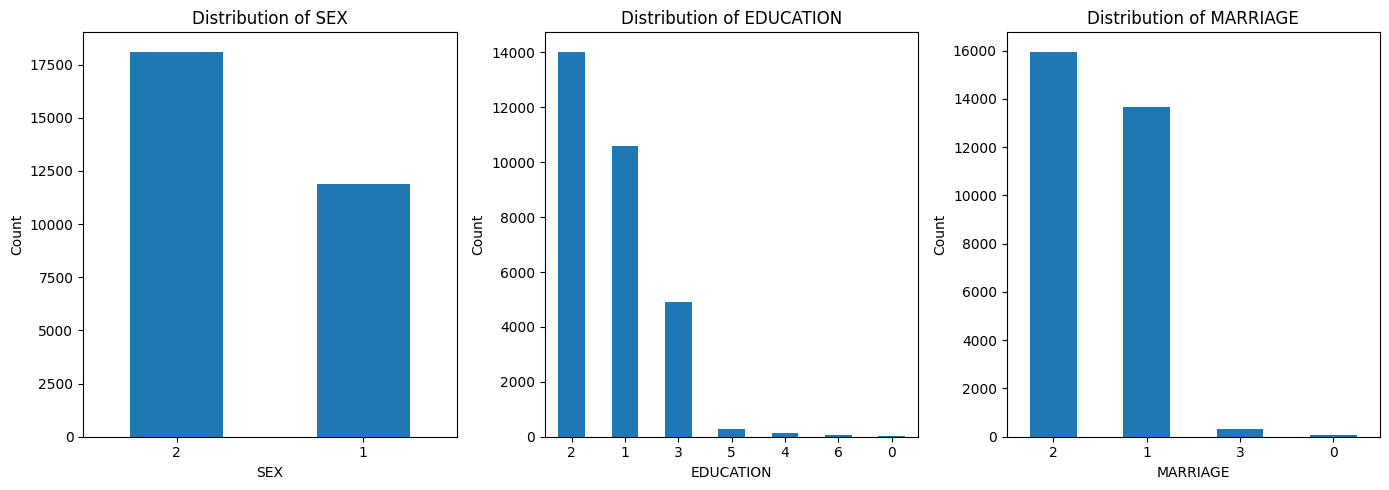

In [29]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(categorical_features):
    df[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(rotation=0)

plt.tight_layout()
plt.show()

**Univariate Analysis - Summary**

- LIMIT_BAL and BILL_AMT columns are right skewed, log transformation recommended
- PAY_AMT columns are extremely right skewed with many zeros, needs careful treatment
- AGE is roughly normally distributed, no issues
- EDUCATION contains undocumented categories (0, 4, 5, 6), needs recoding
- MARRIAGE contains undocumented category (0), needs recoding

**6.5 Bivariate Analysis**

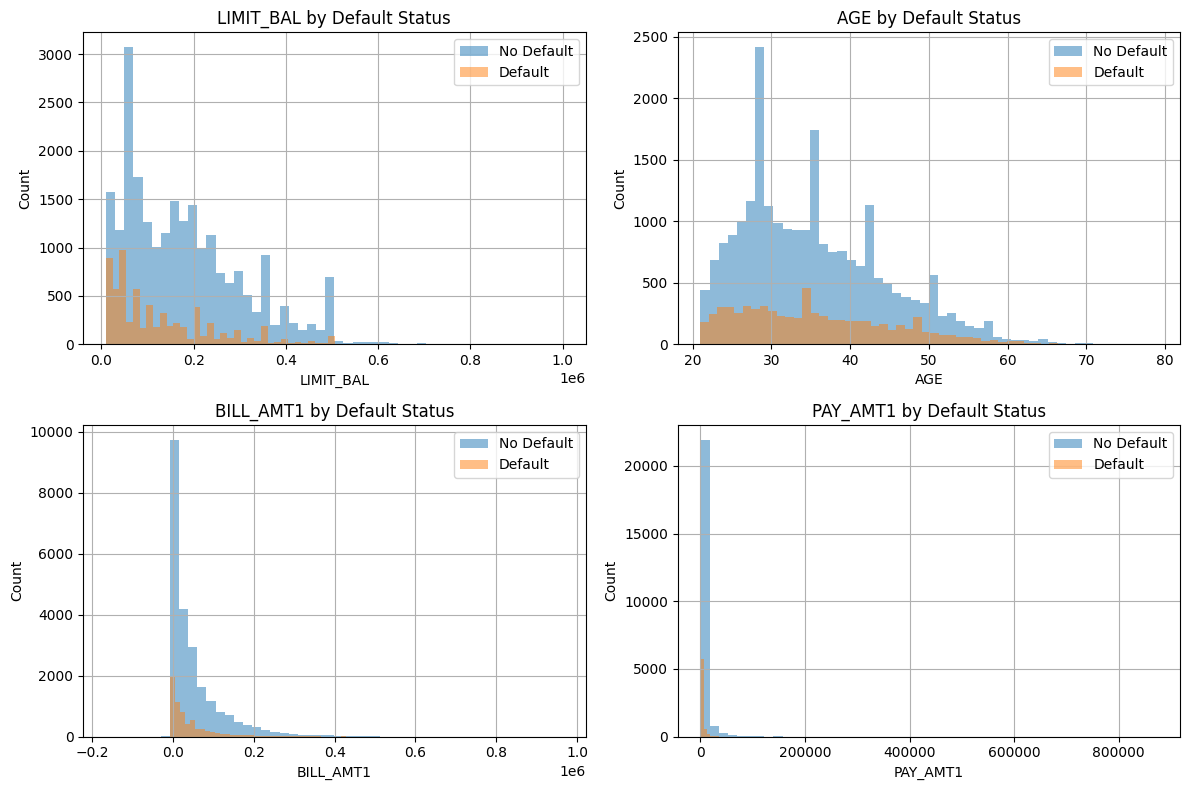

In [30]:
# numeric features already defined. 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    df[df["default.payment.next.month"] == 0][col].hist(
        bins=50, ax=axes[i], alpha=0.5, label="No Default"
    )
    df[df["default.payment.next.month"] == 1][col].hist(
        bins=50, ax=axes[i], alpha=0.5, label="Default"
    )
    axes[i].set_title(f"{col} by Default Status")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.tight_layout()
plt.show()


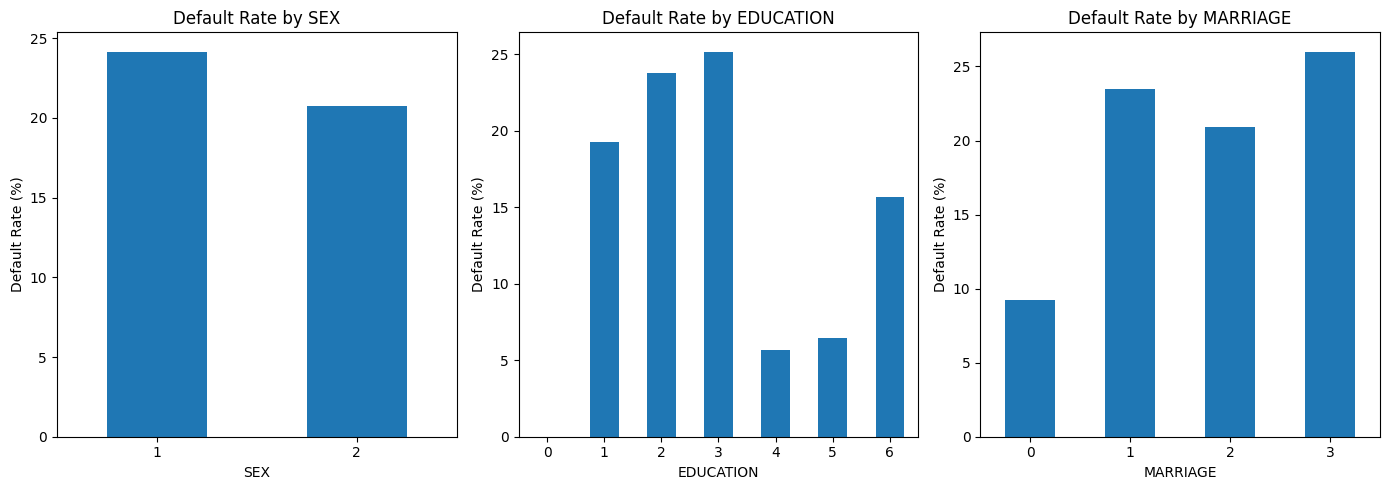

In [31]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(categorical_features):
    default_rate = df.groupby(col)["default.payment.next.month"].mean() * 100
    default_rate.plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Default Rate by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Default Rate (%)")
    axes[i].tick_params(rotation=0)

plt.tight_layout()
plt.show()


**Bivariate Analysis - Summary**

- LIMIT_BAL shows clearest separation between defaulters and non-defaulters
- PAY_AMT and BILL_AMT distributions are too skewed to read visually — transformation needed
- AGE has minimal difference between groups — weak predictor
- Males default slightly more than females
- Higher education correlates with slightly lower default rates
- Undocumented categories in EDUCATION and MARRIAGE show unreliable default rates due to small sample sizes

**6.6 Correlation Analysis**

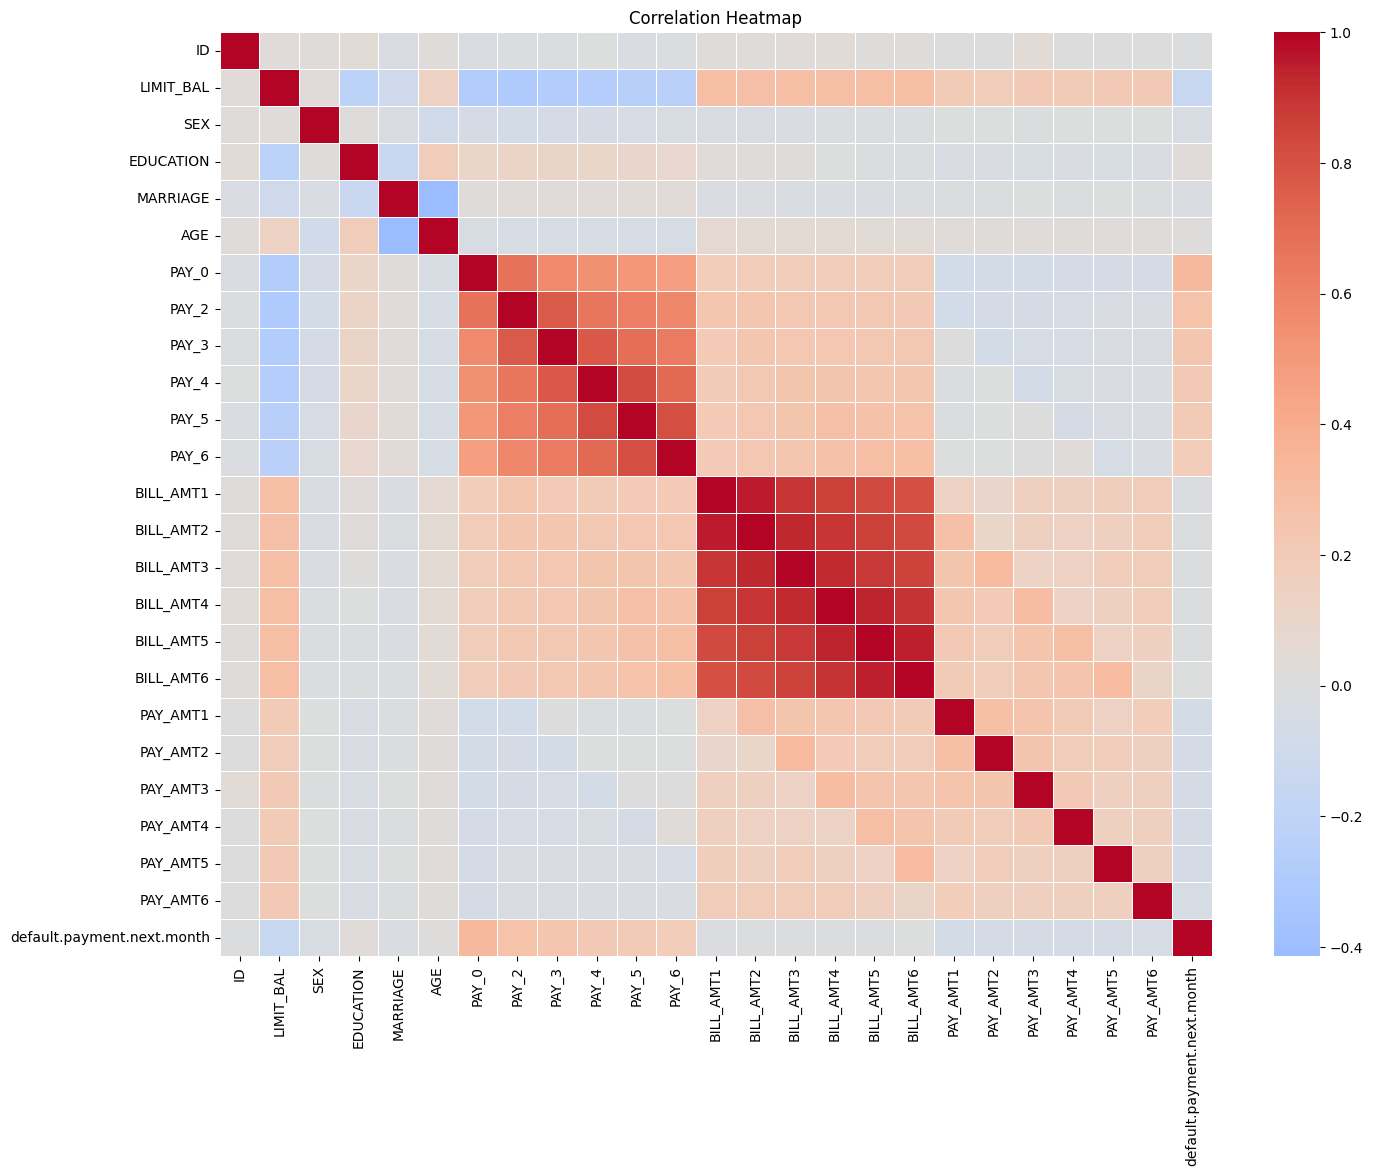

In [32]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [33]:
target_corr = df.corr()["default.payment.next.month"].sort_values(ascending=False)
print(target_corr)

default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default.payment.nex

**C**orrelation Analysis - Summary**

- PAY_0 is the strongest predictor of default (r=0.32)
- All PAY status columns are positively correlated with default
- LIMIT_BAL is the strongest negative predictor (r=-0.15)
- BILL_AMT columns show multicollinearity — highly correlated with each other
- PAY status columns also show multicollinearity
- AGE, EDUCATION, BILL_AMT have near-zero correlation with target — weak predictors
- Multicollinearity in BILL_AMT and PAY columns may require treatment before modelling

**6.7 Outlier Analysis**

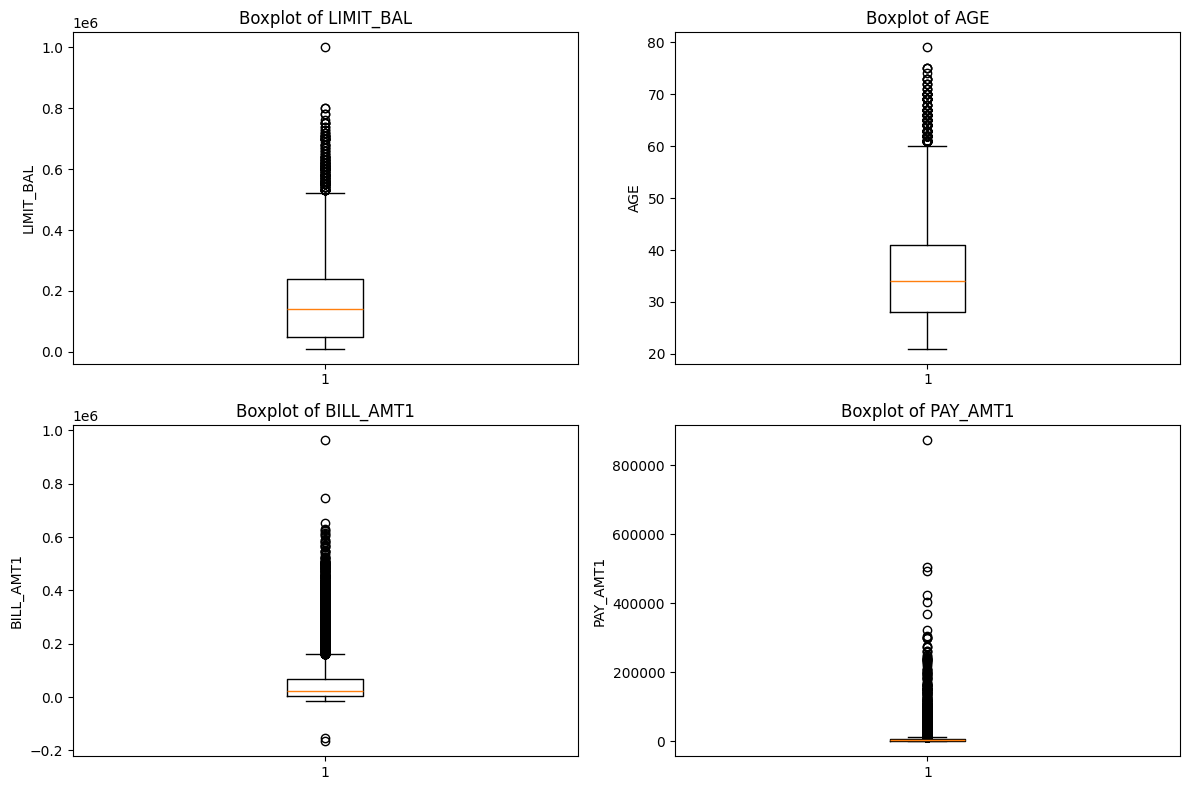

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

numeric_features = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]

for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


In [35]:
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers) / len(df) * 100:.1f}%)")

LIMIT_BAL: 167 outliers (0.6%)
AGE: 272 outliers (0.9%)
BILL_AMT1: 2400 outliers (8.0%)
PAY_AMT1: 2745 outliers (9.2%)


**Outlier Analysis - Summary** 

- LIMIT_BAL and AGE have very few outliers (<1%) — real values, not errors
- BILL_AMT1 and PAY_AMT1 have significant outliers (8-9%) driven by extreme skewness
- Outliers are genuine customer behaviour, not data entry errors — will not be removed
- Log transformation in preprocessing will handle the extreme values in BILL_AMT and PAY_AMT columns

**6.8 EDA Conclusions and Preprocessing Plan**

### Key Findings:
- This dataset has 30,000 customers, 25 features, no missing values, no duplicates
- Target variable is imbalanced: 77.88% no default vs 22.12% default
- PAY_0 is the strongest predictor of default (r=0.32)
- LIMIT_BAL is the strongest negative predictor (r=-0.15)
- BILL_AMT columns are highly correlated with each other, multicollinearity present
- PAY status columns are also highly correlated with each other
- BILL_AMT and PAY_AMT columns are heavily right skewed with many outliers
- EDUCATION and MARRIAGE contain undocumented categories that need recoding
- AGE and BILL_AMT have weak correlation with target

### Preprocessing Plan:
1. Recode EDUCATION: group values 0, 4, 5, 6 into category 3 (other)
2. Recode MARRIAGE: group value 0 into category 3 (other)
3. maybe drop ID column, it is just a row number, not a real feature
4. Log transform BILL_AMT and PAY_AMT columns to handle skewness
5. Scale numeric features using StandardScaler before modelling
6. Use stratified train test split to preserve class balance
7. Use AUC-ROC and/or recall as evaluation metrics, not accuracy (this is not valuable as there is ~78% non defaulting)